## Load the image

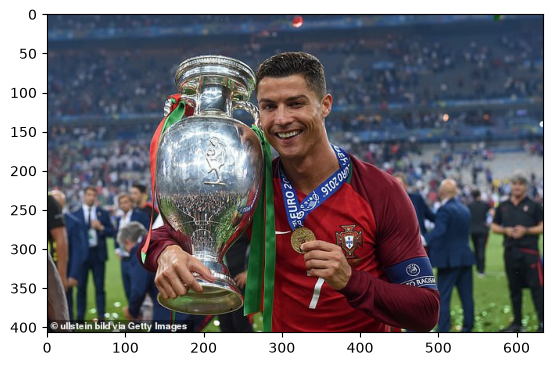

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

image = plt.imread('1.jpeg')

plt.imshow(image)

h, w, d = image.shape

## Grayscale (CPU)

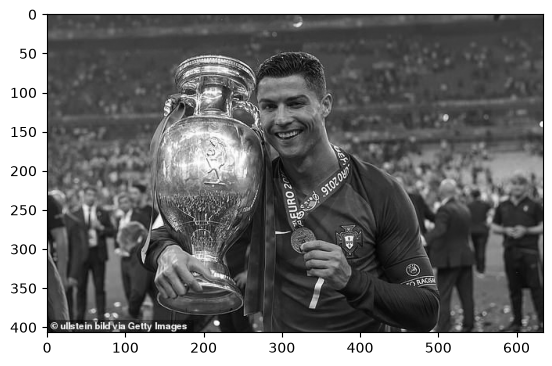

In [2]:
gray = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        gray[y, x] = (int(image[y, x, 0]) + int(image[y, x, 1]) + int(image[y, x, 2])) / 3

plt.imshow(gray, cmap='gray', vmin=0, vmax=255)

## 9a: Histogram (CPU)

In [3]:
histo = np.zeros(256, np.int32)

start = time.time()
for y in range(h):
    for x in range(w):
        histo[gray[y, x]] += 1
print(f"CPU time: {time.time() - start} seconds")

print(f"Total pixels: {histo.sum()} = {h} x {w} = {h * w}")

CPU time: 0.10837769508361816 seconds
Total pixels: 258038 = 407 x 634 = 258038


## Plot the histogram

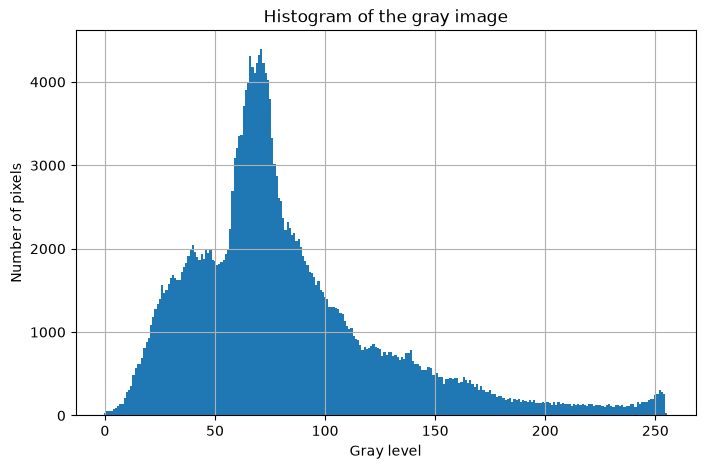

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(range(256), histo, width=1)
plt.xlabel("Gray level")
plt.ylabel("Number of pixels")
plt.title("Histogram of the gray image")
plt.grid(True)
plt.show()

## 9b: Histogram equalization (CPU)

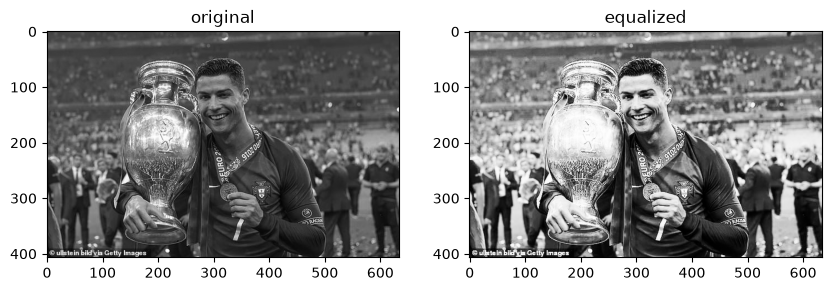

In [5]:
n = h * w

# probability of each gray level
p = np.zeros(256, np.float32)
for j in range(256):
    p[j] = histo[j] / n

# cumulative distribution function
c = np.zeros(256, np.float32)
c[0] = p[0]
for i in range(1, 256):
    c[i] = c[i - 1] + p[i]

# scale c from [0..1] to [0..255]
hmap = np.zeros(256, np.uint8)
for i in range(256):
    hmap[i] = c[i] * 255

# transform each pixel: gray level i becomes hmap[i]
equalized = np.zeros((h, w), np.uint8)
for y in range(h):
    for x in range(w):
        equalized[y, x] = hmap[gray[y, x]]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title("original")
plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title("equalized")
plt.show()

## Histogram before and after equalization

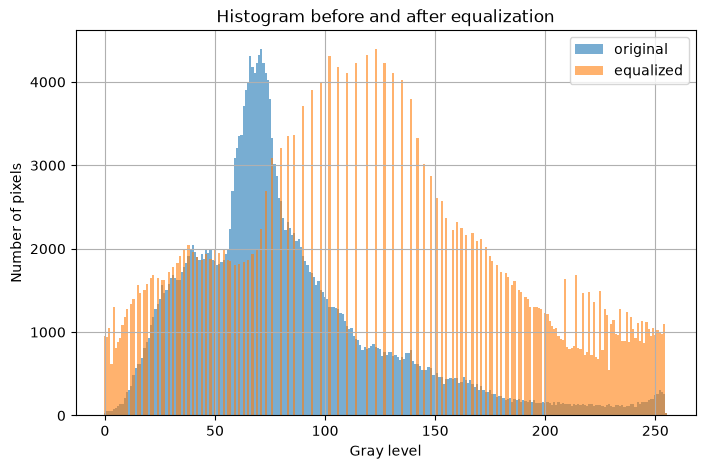

In [6]:
histoEq = np.zeros(256, np.int32)
for y in range(h):
    for x in range(w):
        histoEq[equalized[y, x]] += 1

plt.figure(figsize=(8, 5))
plt.bar(range(256), histo, width=1, alpha=0.6, label='original')
plt.bar(range(256), histoEq, width=1, alpha=0.6, label='equalized')
plt.xlabel("Gray level")
plt.ylabel("Number of pixels")
plt.title("Histogram before and after equalization")
plt.legend()
plt.grid(True)
plt.show()